# Switching linear dynamical systems

A switching linear dynamical system (SLDS) combines a discrete regime $z_t$ with a continuous latent state $x_t$. Each regime selects a different linear dynamical system, while a Markov chain determines when the model switches between regimes.

This tutorial defines the complete model, generates synthetic data with observed control inputs, filters the mixed latent state with a Rao–Blackwellized particle filter, and makes predictive rollouts.

## Model setup

We introduce the model in generative order, beginning with the measured data.

### 1. Observation model

Let $y_t \in \mathbb{R}^{d_y}$ be the observation, $x_t \in \mathbb{R}^{d_x}$ the continuous latent state, $z_t \in \{0,\ldots,K-1\}$ the discrete regime, and $u_t \in \mathbb{R}^{d_u}$ a known control input. We treat $u_t$ as observed rather than latent.

$$
y_t \mid x_t,z_t,u_t
\sim
\mathcal{N}\left(
C_{z_t}x_t + D_{z_t}u_t + d_{z_t},
R_{z_t}
\right).
$$

The active regime selects the observation matrix $C_{z_t}$, optional observation-control matrix $D_{z_t}$, observation bias $d_{z_t}$, and observation-noise covariance $R_{z_t}$.

In this tutorial, the observed control has no direct effect on the observation once $x_t$ is given. We explicitly set

$$
D_{z_t}=0 \qquad \text{for every regime } z_t.
$$

Hence, the observation model used below is

$$
y_t \mid x_t,z_t
\sim
\mathcal{N}\left(
C_{z_t}x_t+d_{z_t},
R_{z_t}
\right).
$$

The control $u_t$ therefore affects $y_t$ only indirectly, through its effect on the latent dynamics via $B_{z_t}u_t$.

### 2. Continuous latent dynamics

Using the convention that $z_t$ labels the dynamics active on the interval from $t$ to $t+1$, the continuous state evolves according to

$$
x_{t+1}
=
A_{z_t}x_t + B_{z_t}u_t + b_{z_t} + \epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0,Q_{z_t}).
$$

Equivalently,

$$
x_{t+1}\mid x_t,z_t,u_t
\sim
\mathcal{N}\left(
A_{z_t}x_t+B_{z_t}u_t+b_{z_t},
Q_{z_t}
\right).
$$

Here $A_{z_t}$ controls the autonomous dynamics and $B_{z_t}$ describes the effect of the observed input. Both can differ across regimes.

The implementation below uses the equivalent destination-state indexing common in SLDS code: $z_{t+1}$ selects the parameters that generate $x_{t+1}$. This is only a one-step relabeling of the regime sequence.

### 3. Switching dynamics

In a conventional SLDS, the regime sequence is a first-order Markov chain:

$$
z_{t+1}\mid z_t
\sim
\operatorname{Categorical}\left(P_{z_t,:}\right),
$$

or, componentwise,

$$
p(z_{t+1}=k\mid z_t=j)=P_{jk},
\qquad
\sum_{k=0}^{K-1}P_{jk}=1.
$$



### Initial conditions

The joint latent process needs initial distributions for both latent variables:

$$
z_0 \sim \operatorname{Categorical}(\pi_0),
$$

$$
x_0\mid z_0=k
\sim
\mathcal{N}(m_{0,k},\Sigma_{0,k}).
$$

Together, these equations define the generative model for $(z_{0:T},x_{0:T},y_{0:T})$ conditional on the observed controls $u_{0:T}$.

## SLDS in Dynestyx

Dynestyx stores the joint latent state as $[z_t,x_t]$: the first scalar is the discrete regime and the remaining entries form the continuous state. The model has these three main components that we use throughout:

- MixedStateDistribution for the initial joint state;
- SwitchingLinearGaussianStateEvolution for the Markov switch and regime-specific continuous dynamics;
- SwitchingLinearGaussianObservation for the observation model.

For inference we use a Rao–Blackwellized particle filter (RBPF). It samples particles over the discrete regime history while analytically marginalizing the conditionally linear-Gaussian state with Kalman updates. 

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel, Filter, flatten_draws
from dynestyx.inference.configs.filter import RBPFConfig
from dynestyx.inference.integrations.cd_dynamax.discrete_filter import (
    compute_cd_dynamax_discrete_filter,
)
from dynestyx.models import (
    MixedStateDistribution,
    SwitchingLinearGaussianObservation,
    SwitchingLinearGaussianStateEvolution,
)

num_regimes = 2
state_dim = 2
observation_dim = 2
control_dim = 1
num_timesteps = 100
train_timesteps = 75

times_full = jnp.arange(float(num_timesteps))
obs_times = times_full[:train_timesteps]
predict_times = times_full[train_timesteps:]

## Observed control inputs

We assume controls u(t) are values supplied to the model. For simulation we create a smooth signal with occasional pulses. During filtering and prediction we pass the corresponding control times and values to the model; dynestyx conditions on these values rather than inferring them.

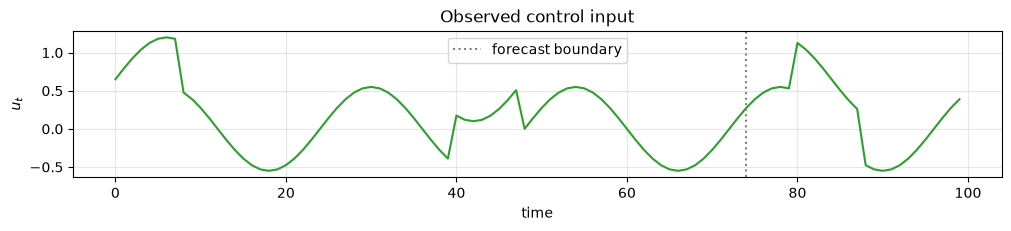

In [2]:
## Generate u(t)

## sin wave control
smooth_control = 0.55 * jnp.sin(2.0 * jnp.pi * times_full / 24.0)
## binary pulse with 0.65 mag
control_pulses = 0.65 * ((times_full % 40.0) < 8.0)
ctrl_values = (smooth_control + control_pulses)[:, None]
ctrl_times = times_full

fig, ax = plt.subplots(figsize=(10, 2.2), constrained_layout=True)
ax.plot(ctrl_times, ctrl_values[:, 0], color="C2")
ax.axvline(float(obs_times[-1]), color="0.5", linestyle=":", label="forecast boundary")
ax.set(xlabel="time", ylabel=r"$u_t$", title="Observed control input")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Initialize synthetic SLDS parameters

The transition matrix $P$ is sticky: both regimes usually persist, but switching remains possible. Each regime has its own state matrix $A_k$, control matrix $B_k$, bias $b_k$, and process covariance $Q_k$. We observe both state coordinates through a two-dimensional observation model. The observation covariance is correlated, which makes the coordinate-wise masking behavior explicit: masking one coordinate must also remove its cross-covariance with the other coordinate.

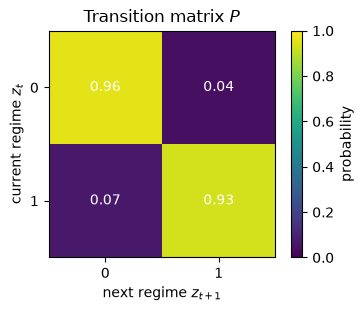

In [3]:
## Assume two regimes here, K=2
transition_matrix = jnp.array([[0.96, 0.04], [0.07, 0.93]])
initial_probs = jnp.array([0.85, 0.15])

## autonomous dynamics matrix
A = jnp.array(
    [
        [[0.94, 0.18], [-0.12, 0.88]],
        [[0.62, -0.26], [0.18, 0.70]],
    ]
)
## input matrix
B = jnp.array(
    [
        [[0.16], [0.02]],
        [[-0.10], [0.14]],
    ]
)
## bias term
b = jnp.array([[0.00, 0.00], [0.55, -0.25]])
Q = jnp.tile(0.07**2 * jnp.eye(state_dim), (num_regimes, 1, 1))

## observation model
C = jnp.tile(jnp.eye(observation_dim)[None, :, :], (num_regimes, 1, 1))
d = jnp.zeros((num_regimes, observation_dim))
observation_cov = jnp.array(
    [
        [0.13**2, 0.35 * 0.13 * 0.18],
        [0.35 * 0.13 * 0.18, 0.18**2],
    ]
)
R = jnp.tile(observation_cov[None, :, :], (num_regimes, 1, 1))

initial_mean = jnp.zeros((num_regimes, state_dim))
initial_cov = jnp.tile(0.40 * jnp.eye(state_dim), (num_regimes, 1, 1))

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
image = ax.imshow(transition_matrix, vmin=0.0, vmax=1.0, cmap="viridis")
for row in range(num_regimes):
    for column in range(num_regimes):
        ax.text(
            column,
            row,
            f"{transition_matrix[row, column]:.2f}",
            ha="center",
            va="center",
            color="white",
        )
ax.set(
    xlabel=r"next regime $z_{t+1}$",
    ylabel=r"current regime $z_t$",
    xticks=range(num_regimes),
    yticks=range(num_regimes),
    title="Transition matrix $P$",
)
fig.colorbar(image, ax=ax, label="probability")
plt.show()

## Define the dynestyx model

MixedStateDistribution implements the two initial-condition equations. SwitchingLinearGaussianStateEvolution combines the categorical transition with the regime-specific linear-Gaussian state dynamics. The observation wrapper selects $C_{z_t}$, $d_{z_t}$, and $R_{z_t}$.

The same model function accepts observation, prediction, and control trajectories, so we can reuse it for simulation, filtering, and forecasting.

In [4]:
## Define dynestyx SLDS model using DynamicalModel


def slds_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    ctrl_times=None,
    ctrl_values=None,
    **kwargs,
):
    state_evolution = SwitchingLinearGaussianStateEvolution(
        transition_matrix=transition_matrix,
        A=A,
        B=B,
        bias=b,
        cov=Q,
    )
    observation_model = SwitchingLinearGaussianObservation(H=C, R=R, bias=d)
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=MixedStateDistribution(
            categorical_probs=initial_probs,
            continuous_locs=initial_mean,
            continuous_covs=initial_cov,
        ),
        state_evolution=state_evolution,
        observation_model=observation_model,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        **kwargs,
    )

## Generate synthetic data

We use DiscreteTimeSimulator to generate samples by drawing from the initial joint state, emitting $y_0$, and applying the switching transition one step at a time. 

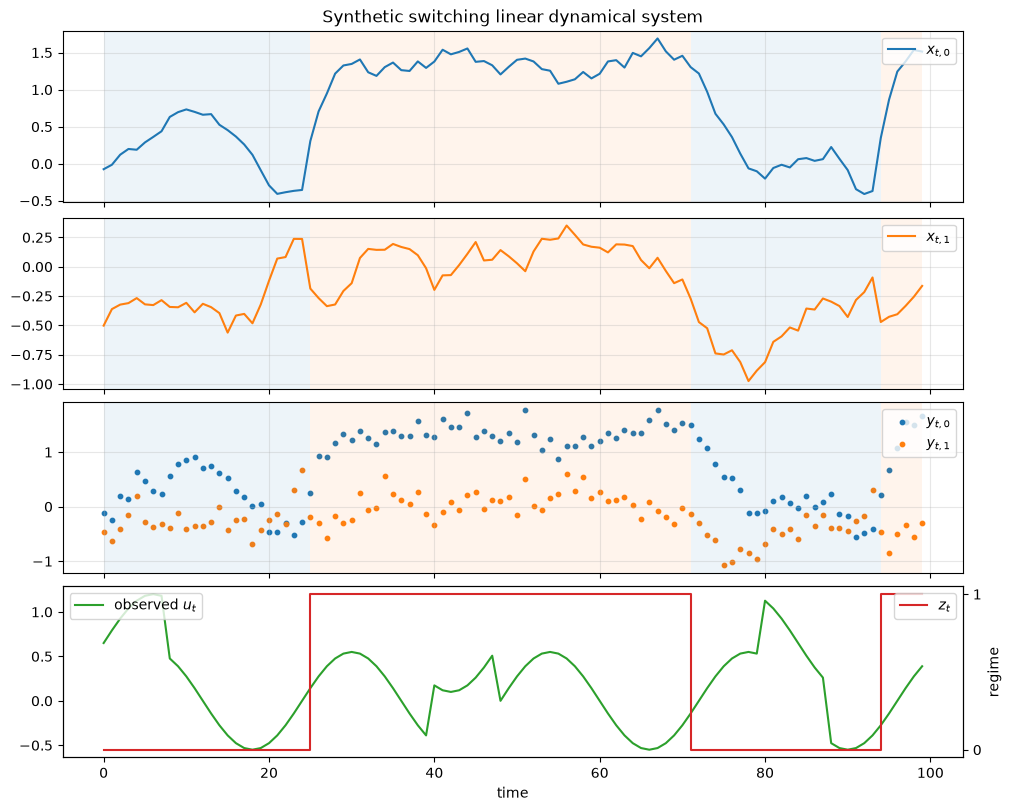

In [5]:
with DiscreteTimeSimulator():
    synthetic = Predictive(
        slds_model,
        num_samples=1,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(0),
        predict_times=times_full,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

times = synthetic["f_times"][0, 0]
joint_states = synthetic["f_states"][0, 0]
true_regimes = joint_states[:, 0].astype(int)
true_states = joint_states[:, 1:]
observations = synthetic["f_observations"][0, 0]

obs_values = observations[:train_timesteps]
states_train = true_states[:train_timesteps]
regimes_train = true_regimes[:train_timesteps]


def shade_regimes(ax, plot_times, regimes, alpha=0.08):
    for t0, t1, z in zip(plot_times[:-1], plot_times[1:], regimes[:-1]):
        ax.axvspan(float(t0), float(t1), color=f"C{int(z)}", alpha=alpha, lw=0)


fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
for index in range(state_dim):
    axes[index].plot(
        times, true_states[:, index], color=f"C{index}", label=rf"$x_{{t,{index}}}$"
    )
    shade_regimes(axes[index], times, true_regimes)
    axes[index].legend(loc="upper right")
    axes[index].grid(True, alpha=0.3)

for index in range(observation_dim):
    axes[2].scatter(
        times,
        observations[:, index],
        s=10,
        color=f"C{index}",
        label=rf"$y_{{t,{index}}}$",
    )
shade_regimes(axes[2], times, true_regimes)
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, ctrl_values[:, 0], color="C2", label=r"observed $u_t$")
regime_axis = axes[3].twinx()
regime_axis.step(times, true_regimes, where="post", color="C3", label=r"$z_t$")
regime_axis.set_yticks(range(num_regimes))
regime_axis.set_ylabel("regime")
axes[3].legend(loc="upper left")
regime_axis.legend(loc="upper right")
axes[3].set_xlabel("time")
axes[0].set_title("Synthetic switching linear dynamical system")
plt.show()

## Inferring $P$ and $W$ with missing observations

The simulation above treats every model parameter as known. We now infer the regime-transition matrix $P$ and the off-diagonal state-coupling coefficients $W$ from observations with synthetic missingness. The diagonal entries of $A_k$, the control effects, biases, and noise covariances remain fixed so that this short example focuses on the switching and coupling structure.

For regime $k$, write

$$
A_k(W_k) =
\begin{bmatrix}
(A_k)_{11} & (W_k)_{12} \
(W_k)_{21} & (A_k)_{22}
\end{bmatrix}.
$$

We consider two observation patterns: entries removed independently at random, and a contiguous block removed from both observation coordinates. Missing entries are represented by `NaN`.

In [6]:
# Generate several independent trajectories that share the same P and W.
N_INFERENCE_TRAJECTORIES = 12
RANDOM_MISSING_FRACTION = 0.30
BLOCK_LENGTH = 20

with DiscreteTimeSimulator():
    inference_simulations = Predictive(
        slds_model,
        num_samples=N_INFERENCE_TRAJECTORIES,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(20),
        predict_times=obs_times,
        ctrl_times=obs_times,
        ctrl_values=ctrl_values[:train_timesteps],
    )

inference_observations = np.asarray(
    flatten_draws(inference_simulations["f_observations"])
)
inference_joint_states = np.asarray(flatten_draws(inference_simulations["f_states"]))
inference_states = inference_joint_states[..., 1:]
inference_controls = np.broadcast_to(
    np.asarray(ctrl_values[:train_timesteps]),
    (N_INFERENCE_TRAJECTORIES, train_timesteps, control_dim),
).copy()

missing_rng = np.random.default_rng(21)
random_valid = (
    missing_rng.random(inference_observations.shape) >= RANDOM_MISSING_FRACTION
)
random_valid[:, 0, :] = True

block_valid = np.ones_like(inference_observations, dtype=bool)
for trajectory in range(N_INFERENCE_TRAJECTORIES):
    start = 18 + 3 * (trajectory % 5)
    block_valid[trajectory, start : start + BLOCK_LENGTH, :] = False

masked_observations = {
    "random": np.where(random_valid, inference_observations, np.nan),
    "block": np.where(block_valid, inference_observations, np.nan),
}

print(
    "observed fractions:",
    {
        name: float(np.isfinite(values).mean())
        for name, values in masked_observations.items()
    },
)

observed fractions: {'random': 0.7105555555555556, 'block': 0.7333333333333333}


### MAP inference with an RBPF likelihood

We place row-wise Dirichlet priors on $P$ and Gaussian priors on $W$. A Rao-Blackwellized particle filter samples the discrete regime histories while analytically marginalizing the conditionally linear-Gaussian states. Its marginal likelihood is optimized with `SVI` and an `AutoDelta` guide, so the estimates below are MAP point estimates rather than posterior samples.

The same controls are supplied as known inputs. For each missingness pattern, one shared $(P,W)$ pair is fitted across all trajectories. Recovery is summarized by normalized errors for $P$ and $W$, together with the RMSE of the RBPF filtered state means.

In [ ]:
W_true = jnp.stack(
    [A[:, 0, 1], A[:, 1, 0]],
    axis=-1,
)
A_diagonal = jnp.diagonal(A, axis1=-2, axis2=-1)


def dynamics_from_P_W(P_value, W_value):
    inferred_A = jnp.zeros_like(A)
    inferred_A = inferred_A.at[:, 0, 0].set(A_diagonal[:, 0])
    inferred_A = inferred_A.at[:, 1, 1].set(A_diagonal[:, 1])
    inferred_A = inferred_A.at[:, 0, 1].set(W_value[:, 0])
    inferred_A = inferred_A.at[:, 1, 0].set(W_value[:, 1])
    return DynamicalModel(
        control_dim=control_dim,
        initial_condition=MixedStateDistribution(
            categorical_probs=initial_probs,
            continuous_locs=initial_mean,
            continuous_covs=initial_cov,
        ),
        state_evolution=SwitchingLinearGaussianStateEvolution(
            transition_matrix=P_value,
            A=inferred_A,
            B=B,
            bias=b,
            cov=Q,
        ),
        observation_model=SwitchingLinearGaussianObservation(H=C, R=R, bias=d),
    )


INFERENCE_FILTER_CONFIG = RBPFConfig(
    n_particles=12,
    proposal="optimal",
    crn_seed=jr.PRNGKey(22),
)
EVALUATION_FILTER_CONFIG = RBPFConfig(
    n_particles=64,
    proposal="optimal",
)
P_CONCENTRATION = jnp.array([[6.0, 2.0], [2.0, 6.0]])
W_PRIOR_SCALE = 0.35
MAP_STEPS = 150


def parameter_model(observations_for_fit):
    P_value = numpyro.sample(
        "P",
        dist.Dirichlet(P_CONCENTRATION).to_event(1),
    )
    W_value = numpyro.sample(
        "W",
        dist.Normal(jnp.zeros_like(W_true), W_PRIOR_SCALE).to_event(2),
    )
    dynamics = dynamics_from_P_W(P_value, W_value)
    with Filter(filter_config=INFERENCE_FILTER_CONFIG):
        with dsx.plate("fit_trajectories", N_INFERENCE_TRAJECTORIES):
            return dsx.sample(
                "fit",
                dynamics,
                obs_times=obs_times,
                obs_values=observations_for_fit,
                ctrl_times=obs_times,
                ctrl_values=inference_controls,
            )


INITIAL_VALUES = {
    "P": jnp.array([[0.85, 0.15], [0.15, 0.85]]),
    "W": jnp.zeros_like(W_true),
}
guide = AutoDelta(
    parameter_model,
    init_loc_fn=init_to_value(values=INITIAL_VALUES),
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(1e-2),
)
svi = SVI(parameter_model, guide, optimizer, Trace_ELBO())


def fit_parameters(key, observations_for_fit):
    result = svi.run(
        rng_key=key,
        num_steps=MAP_STEPS,
        observations_for_fit=jnp.asarray(observations_for_fit),
        progress_bar=True,
    )
    params, losses = result.params, result.losses
    return guide.median(params), np.asarray(losses)


fits = {}
losses = {}
for index, (name, observations_for_fit) in enumerate(masked_observations.items()):
    fits[name], losses[name] = fit_parameters(
        jr.PRNGKey(30 + index), observations_for_fit
    )
    print(name, "final loss:", losses[name][-1])

random final loss: -155.91943359375


block final loss: -197.66644287109375



random missingness
estimated P:
 [[0.958 0.042]
 [0.094 0.906]]
estimated W:
 [[ 0.177 -0.119]
 [-0.288  0.181]]
{'P error': 0.025, 'W error': 0.073, 'state RMSE': 0.108}



block missingness
estimated P:
 [[0.957 0.043]
 [0.11  0.89 ]]
estimated W:
 [[ 0.172 -0.101]
 [-0.289  0.188]]
{'P error': 0.042, 'W error': 0.094, 'state RMSE': 0.21}


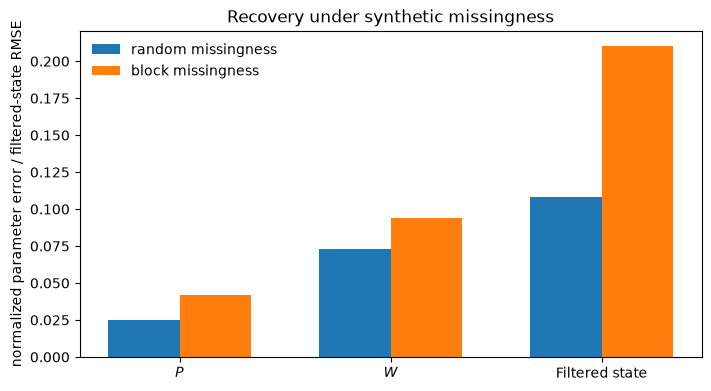

In [8]:
def normalized_error(estimate, truth):
    return float(jnp.linalg.norm(estimate - truth) / jnp.linalg.norm(truth))


def filtered_state_rmse(P_value, W_value, observations_for_fit, key):
    dynamics = dynamics_from_P_W(P_value, W_value)

    def filter_one(observations, controls, filter_key):
        output = compute_cd_dynamax_discrete_filter(
            dynamics,
            EVALUATION_FILTER_CONFIG,
            key=filter_key,
            obs_times=obs_times,
            obs_values=observations,
            ctrl_times=obs_times,
            ctrl_values=controls,
        )
        return output.filtered_means

    filtered_means = jax.vmap(filter_one)(
        jnp.asarray(observations_for_fit),
        jnp.asarray(inference_controls),
        jr.split(key, N_INFERENCE_TRAJECTORIES),
    )
    return float(
        jnp.sqrt(jnp.mean((filtered_means - jnp.asarray(inference_states)) ** 2))
    )


metrics = {}
for index, name in enumerate(masked_observations):
    metrics[name] = {
        "P error": normalized_error(fits[name]["P"], transition_matrix),
        "W error": normalized_error(fits[name]["W"], W_true),
        "state RMSE": filtered_state_rmse(
            fits[name]["P"],
            fits[name]["W"],
            masked_observations[name],
            jr.PRNGKey(40 + index),
        ),
    }
    print(f"\n{name} missingness")
    print("estimated P:\n", np.round(np.asarray(fits[name]["P"]), 3))
    print("estimated W:\n", np.round(np.asarray(fits[name]["W"]), 3))
    print({metric: round(value, 3) for metric, value in metrics[name].items()})

metric_names = ("P error", "W error", "state RMSE")
x = np.arange(len(metric_names))
width = 0.34
fig, axis = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
for offset, (name, values) in zip((-0.5, 0.5), metrics.items()):
    axis.bar(
        x + offset * width,
        [values[metric] for metric in metric_names],
        width,
        label=f"{name} missingness",
    )
axis.set(
    xticks=x,
    xticklabels=("$P$", "$W$", "Filtered state"),
    ylabel="normalized parameter error / filtered-state RMSE",
    title="Recovery under synthetic missingness",
)
axis.legend(frameon=False)
plt.show()

The two fits use identical dynamics, controls, and priors; only the observation mask changes. During missing data intervals the RBPF propagates the latent state using the learned dynamics and resumes measurement updates when observations return. The reported spread between the two cases reflects the information retained by each synthetic mask pattern (i.e random missingness vs block missingness).

## Posterior predictive rollout

We now condition the fitted SLDS on the first 75 observations and roll it forward over the held-out interval. At each future time, the simulator samples both the discrete regime and the continuous state from the RBPF posterior, then samples an observation from the corresponding observation model. The predictive interval therefore shows state, regime, process, and observation uncertainty conditional on the MAP estimates of $P$ and $W$.

The black points are the observations used for filtering. The dashed black line is held out from inference and is shown only to assess the forecast. The lower panel compares the forecast probability $p(z_t=1)$ with the held-out regime sequence.


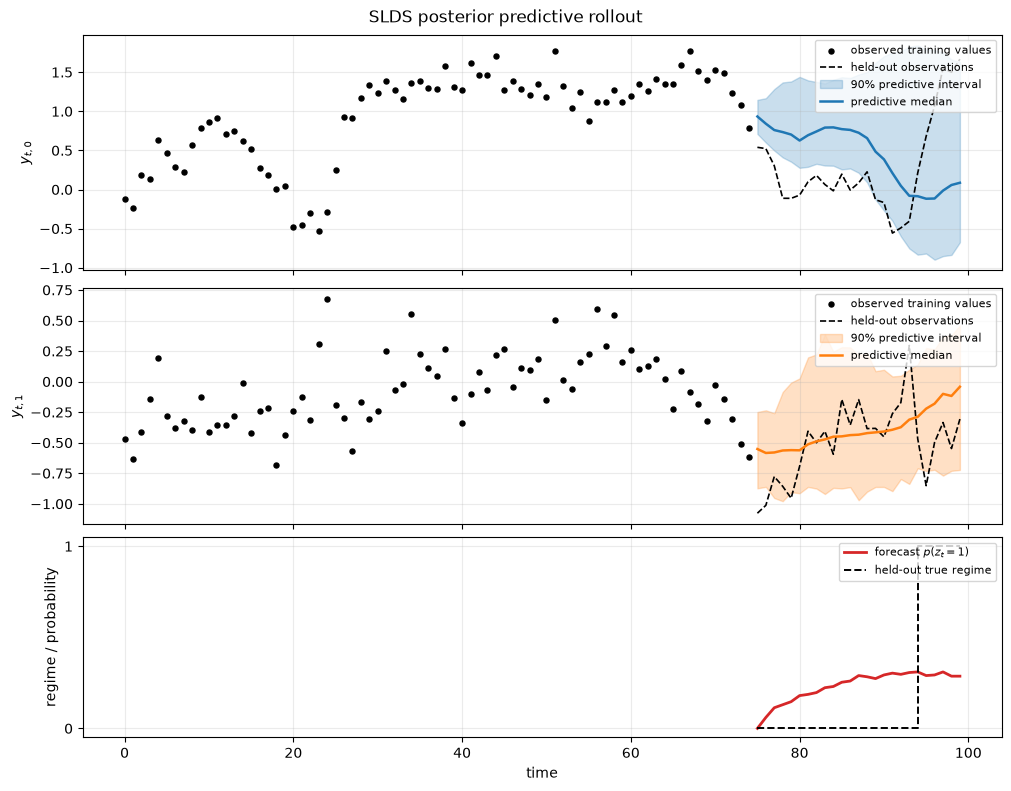

In [9]:
# Forecast from the fit learned with randomly missing training values.
rollout_dynamics = dynamics_from_P_W(
    fits["random"]["P"],
    fits["random"]["W"],
)


def posterior_rollout_model():
    return dsx.sample(
        "rollout",
        rollout_dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


ROLLOUT_DRAWS = 300
ROLLOUT_FILTER_CONFIG = RBPFConfig(
    n_particles=128,
    proposal="optimal",
)

with DiscreteTimeSimulator(n_simulations=ROLLOUT_DRAWS):
    with Filter(filter_config=ROLLOUT_FILTER_CONFIG):
        rollout_samples = Predictive(
            posterior_rollout_model,
            num_samples=1,
            exclude_deterministic=False,
        )(jr.PRNGKey(50))

rollout_times = np.asarray(flatten_draws(rollout_samples["rollout_predicted_times"])[0])
rollout_observations = np.asarray(
    flatten_draws(rollout_samples["rollout_predicted_observations"])
)
rollout_joint_states = np.asarray(
    flatten_draws(rollout_samples["rollout_predicted_states"])
)
rollout_regimes = rollout_joint_states[..., 0].astype(int)

predictive_lower, predictive_median, predictive_upper = np.percentile(
    rollout_observations,
    [5.0, 50.0, 95.0],
    axis=0,
)
regime_one_probability = np.mean(rollout_regimes == 1, axis=0)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 7.8),
    sharex=True,
    constrained_layout=True,
    height_ratios=(1.0, 1.0, 0.85),
)

for dimension, (axis, color) in enumerate(zip(axes[:2], ("C0", "C1"))):
    axis.scatter(
        obs_times,
        obs_values[:, dimension],
        s=13,
        color="black",
        label="observed training values",
        zorder=3,
    )
    axis.plot(
        predict_times,
        observations[train_timesteps:, dimension],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="held-out observations",
    )
    axis.fill_between(
        rollout_times,
        predictive_lower[:, dimension],
        predictive_upper[:, dimension],
        color=color,
        alpha=0.24,
        label="90% predictive interval",
    )
    axis.plot(
        rollout_times,
        predictive_median[:, dimension],
        color=color,
        linewidth=1.8,
        label="predictive median",
    )
    axis.set_ylabel(rf"$y_{{t,{dimension}}}$")
    axis.grid(True, alpha=0.25)
    axis.legend(loc="upper right", fontsize=8, frameon=True)

axes[2].plot(
    rollout_times,
    regime_one_probability,
    color="C3",
    linewidth=2.0,
    label=r"forecast $p(z_t=1)$",
)
axes[2].step(
    predict_times,
    true_regimes[train_timesteps:],
    where="post",
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="held-out true regime",
)
axes[2].set(
    xlabel="time",
    ylabel="regime / probability",
    ylim=(-0.05, 1.05),
    yticks=(0.0, 1.0),
)
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right", fontsize=8, frameon=True)

fig.suptitle("SLDS posterior predictive rollout")
plt.show()